In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score

# --- BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP ---
np.random.seed(42)
people = 100

tuoi = np.random.randint(18,70, people)
luong = np.random.randint(2000, 20000, people)

xac_suat = (tuoi * 0.05) + (luong *0.001) + np.random.normal(0, 1, people)
mua_xe = (xac_suat > 13).astype(int)

df_ads = pd.DataFrame({
    "Tuổi": tuoi,
    "Lương ($)": luong,
    "Xác suất mua xe": xac_suat,
    "Mua xe": mua_xe
})

print(df_ads.head())

# --- BƯỚC 2: HUẤN LUYỆN AI ---
X = df_ads[["Tuổi", "Lương ($)"]]
y = df_ads["Mua xe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# --- BƯỚC 3: KIỂM TRA ---
y_pred = model.predict(X_test)

kqt = pd.DataFrame({
    "Tuổi": X_test["Tuổi"],
    "Lương ($)": X_test["Lương ($)"],
    "Tỉ lệ thực tế": y_test.values.flatten(),
    "Tỉ lệ AI dự đoán": y_pred.flatten()
})

print(kqt.head())
print(f"Độ chính xác của AI: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Trọng số AI tìm được (w1, w2):", model.coef_)
print("Con số AI tự trừ đi (b - Intercept):", model.intercept_)

   Tuổi  Lương ($)  Xác suất mua xe  Mua xe
0    56      18448        19.697337       1
1    69      18216        21.734563       1
2    46      10006        11.243696       0
3    32       4568         6.641592       0
4    60       4027         6.107576       0
    Tuổi  Lương ($)  Tỉ lệ thực tế  Tỉ lệ AI dự đoán
83    32       6931              0                 0
53    43      12173              1                 1
70    23       8585              0                 0
45    26      12921              1                 1
44    38      12817              1                 1
Độ chính xác của AI: 95.00%
Trọng số AI tìm được (w1, w2): [[0.05066742 0.00136424]]
Con số AI tự trừ đi (b - Intercept): [-16.94783824]


In [17]:
# Dự đoán xác suất thay vì chỉ dự đoán 0/1
y_pred_prob = model.predict_proba(X_test)[:, 1 ]  # Lấy xác suất của lớp 1 (mua xe)
kqt_nang_cao = pd.DataFrame({
    "Tuổi": X_test["Tuổi"],
    "Lương ($)": X_test["Lương ($)"],
    "Tỉ lệ thực tế": y_test.values.flatten(),
    "Tỉ lệ AI dự đoán (0/1)": y_pred.flatten(),
    "Xác suất AI dự đoán mua xe": np.round(y_pred_prob.flatten() *100, 2)
})

print(kqt_nang_cao.head())

    Tuổi  Lương ($)  Tỉ lệ thực tế  Tỉ lệ AI dự đoán (0/1)  \
83    32       6931              0                       0   
53    43      12173              1                       1   
70    23       8585              0                       0   
45    26      12921              1                       1   
44    38      12817              1                       1   

    Xác suất AI dự đoán mua xe  
83                        0.28  
53                       86.27  
70                        1.68  
45                       88.05  
44                       92.15  


c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


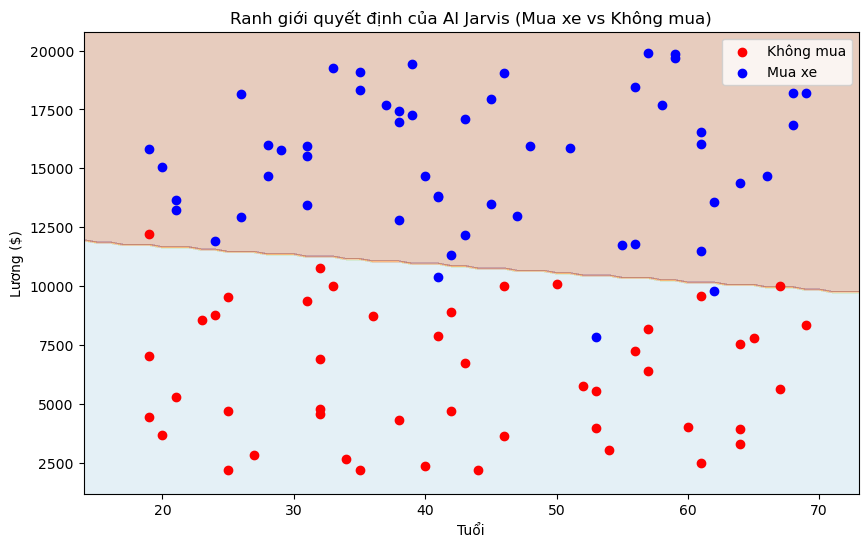

In [ ]:
# Tạo lưới để vẽ vùng màu (Meshgrid)
h = 100  # Độ phân giải của lưới
x_min, x_max = X["Tuổi"].min() - 5, X["Tuổi"].max() + 5
y_min, y_max = X["Lương ($)"].min() - 1000, X["Lương ($)"].max() + 1000
xx, yy = np.meshgrid(np.arange(x_min, x_max, 1),
                     np.arange(y_min, y_max, h))

# Dự đoán cho từng điểm trên lưới
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
# Vẽ vùng màu ranh giới
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

# Vẽ các điểm dữ liệu thực tế
plt.scatter(df_ads[df_ads["Mua xe"] == 0]["Tuổi"], 
            df_ads[df_ads["Mua xe"] == 0]["Lương ($)"], 
            color='red', label='Không mua')
plt.scatter(df_ads[df_ads["Mua xe"] == 1]["Tuổi"], 
            df_ads[df_ads["Mua xe"] == 1]["Lương ($)"], 
            color='blue', label='Mua xe')

plt.title("Ranh giới quyết định của AI Jarvis (Mua xe vs Không mua)")
plt.xlabel("Tuổi")
plt.ylabel("Lương ($)")
plt.legend()
plt.show()


--- NGÀY 50: ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI ---


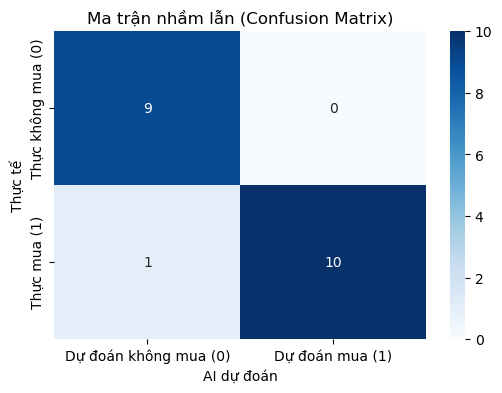


BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.91      0.95        11

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- NGÀY 50: ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI ---")

# 1. Tạo Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# 2. Vẽ Ma trận cho đẹp bằng Seaborn
# Thực Y nằm - Dự X đứng
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels = ["Dự đoán không mua (0)","Dự đoán mua (1)"],
            yticklabels = ["Thực không mua (0)", "Thực mua (1)"] )

plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.xlabel("AI dự đoán")
plt.ylabel("Thực tế")
plt.show()

# 3. In Báo cáo phân loại chi tiết (Classification Report) 
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(y_test, y_pred))

In [26]:
from sklearn.neighbors import KNeighborsClassifier

print("\n--- NGÀY 51: DÙNG THUẬT TOÁN KNN (K-Nearest Neighbors) ---")

#khoi tao mo hinh
model = KNeighborsClassifier(n_neighbors = 5)

#huon luyen mo hinh
model.fit(X_train, y_train)
y_pred_knn = model.predict(X_test)

#so sanh do chinh xac voi logistic regression
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Độ chính xác của KNN: {acc_knn:.2f}")

print("Ma trận nhầm lẫn của KNN")
print(confusion_matrix(y_test, y_pred_knn))



--- NGÀY 51: DÙNG THUẬT TOÁN KNN (K-Nearest Neighbors) ---
Độ chính xác của KNN: 0.95
Ma trận nhầm lẫn của KNN
[[ 9  0]
 [ 1 10]]


In [ ]:
from sklearn.tree import  DecisionTreeClassifier, export_text

print("\n--- NGÀY 52: DÙNG THUẬT TOÁN DECISION TREE ---")

#khoi tao mo hinh
model_tree = DecisionTreeClassifier(random_state=42)

#huan luyen(fit) va du doan(predict) mo hinh
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

#danh gia do chinh xac
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Độ chính xác của Decision Tree: {acc_tree:.2f}")

print("Ma trận nhầm lẫn của Decision Tree")
print(confusion_matrix(y_test, y_pred_tree))

# 4. Đọc suy nghĩ của AI (In cây quyết định ra màn hình)
print("\nSƠ ĐỒ TƯ DUY CỦA AI (IF/ELSE):")
law_ai = export_text(model_tree, feature_names=["Tuổi", "Lương ($)"])
print(law_ai)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- NGÀY 53: DÙNG THUẬT TOÁN RANDOM FOREST (RỪNG NGẪU NHIÊN) ---")

#khoi tao mo hinh 
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

#huan luyen mo hinh
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

#danh gia do chinh xac
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Độ chính xác của Random Forest: {acc_rf:.2f}")

print("Ma trận nhầm lẫn của Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

importances = model_rf.feature_importances_
for i, v in enumerate(importances):
    print(f"Độ quan trọng của {X.columns[i]}: {v*100:.2f}%")


--- NGÀY 53: DÙNG THUẬT TOÁN RANDOM FOREST (RỪNG NGẪU NHIÊN) ---
Độ chính xác của Random Forest: 0.95
Ma trận nhầm lẫn của Random Forest
[[ 9  0]
 [ 1 10]]
Độ quan trọng của Tuổi: 11.82%
Độ quan trọng của Lương ($): 88.18%


In [35]:
from sklearn.model_selection import cross_val_score

print("\n--- NGÀY 54: ĐÁNH GIÁ MÔ HÌNH BẰNG CROSS-VALIDATION ---")

scores = cross_val_score(model_rf, X, y, cv=5)

print(f"Điểm số của 5 lần thi: {scores}")
print(f"Điểm trung bình của 5 lần thi:{scores.mean():.2f} ")
print(f"Độ lệch chuẩn của 5 lần thi (sai số giữa các lần thi): {scores.std():.2f}")


--- NGÀY 54: ĐÁNH GIÁ MÔ HÌNH BẰNG CROSS-VALIDATION ---
Điểm số của 5 lần thi: [0.95 0.9  0.95 0.95 0.95]
Điểm trung bình của 5 lần thi:0.94 
Độ lệch chuẩn của 5 lần thi (sai số giữa các lần thi): 0.02
